# Dataset-Based Neuron Visualization

## Configuration
- **Model**: Pre-trained InceptionV1 (GoogLeNet) with ImageNet weights
- **Dataset**: ImageNet validation set
- **Target Layer**: `mixed4a`
- **Target Neurons**: First 10 channels
- **Activation Metric**: Maximum spatial activation

In [34]:
import torch
import torchvision.models as models
from torchvision import transforms

from torchvision.datasets import ImageNet
from torch.utils.data import DataLoader

from lucent.modelzoo import inceptionv1

from PIL import Image
from torch.utils.data import Dataset
import os

---

## Step 1: Load Pre-trained Model

### Objectives
- Load InceptionV1 with ImageNet pre-trained weights
- Set the model to evaluation mode
- Freeze all parameters (no gradients required)

In [35]:
# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Load pre-trained InceptionV1 (GoogLeNet)
# model = models.googlenet(
#     weights=models.GoogLeNet_Weights.IMAGENET1K_V1,
#     aux_logits=True
# )

# # Move model to device
# model = model.to(device)

model = inceptionv1(pretrained=True).to(device)


# Set to evaluation mode
model.eval()

# Freeze all parameters (not strictly required, but good practice)
for param in model.parameters():
    param.requires_grad = False

print("Model loaded and ready for interpretability analysis.")

Model loaded and ready for interpretability analysis.


## Step 2: Prepare ImageNet Preprocessing

### Preprocessing Steps
For each image:
1. Resize the shorter side to 256
2. Center crop to 224 × 224
3. Convert to tensor
4. Normalize using ImageNet mean and standard deviation

### Why This is Necessary

**Interpretability only makes sense if the model sees images in the same form it was trained on.**

#### 🎯 Matching the Training Distribution

InceptionV1 was trained on ImageNet images that were:
- Resized
- Cropped  
- Normalized with specific mean and std

If you skip or change this:
- ❌ Activations shift
- ❌ Neurons fire differently
- ❌ "Top-activating images" become meaningless

> **Key Point**: Preprocessing is about distribution alignment, not aesthetics.

In [36]:
# ImageNet normalization statistics
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Preprocessing pipeline
preprocess = transforms.Compose([
    transforms.Resize(256),          # resize shorter side to 256
    transforms.CenterCrop(224),       # crop to 224x224
    transforms.ToTensor(),            # convert PIL image to tensor [0, 1]
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

## Step 3: Register a Forward Hook

### Objectives
- Attach a forward hook to the `mixed4a` layer
- Store its output tensor during forward passes
- Do not modify the network or gradients

### What This Does (Mechanically)

`model.mixed4a` is the `mixed4a` layer in InceptionV1.

Every time you do:
```python
model(images)
```

PyTorch will:
1. Run the layer normally
2. Call `mixed4a_hook`
3. Store the layer's output in `activations["mixed4a"]`

The stored tensor has shape:
```
(batch_size, num_channels, H, W)
```

> **Note**: Each channel = one neuron/filter.

In [37]:
# Dictionary to store activations
activations = {}

def mixed4a_hook(module, input, output):
    """
    Forward hook function to capture mixed4a activations.
    output shape: (batch_size, channels, height, width)
    """
    activations["mixed4a"] = output.detach()

# Register hook on mixed4a layer
hook_handle = model.mixed4a.register_forward_hook(mixed4a_hook)

print("Forward hook registered on mixed4a.")


Forward hook registered on mixed4a.


In [6]:
activations

{}

## Step 4: Define the Activation Metric and Select the First 10 Neurons

### Tasks
1. Define what "activation strength" means
2. Select the first 10 neurons (channels) of `mixed4a`
3. Compute a scalar score per neuron per image

### Why Step 4 is Necessary (Conceptual)

#### 🧠 What does "neuron activation" mean in a CNN?

In convolutional layers:
- A "neuron" ≈ one channel / filter
- Each neuron produces a feature map (H × W)
- You must reduce that map to one number to compare images

**Step 4 answers**: *How strongly did this neuron respond to this image?*

### Why Use Max Activation?

```python
scores = selected.amax(dim=(2, 3))
```

This means: **Did this neuron fire anywhere strongly in the image?**

### Alternative Metrics

| Metric | Meaning | When to Use |
|--------|---------|-------------|
| `max` | Strongest local response | Feature presence |
| `mean` | Overall response | Texture-like features |
| `sum` | Total energy | Dense activations |
| `L2 norm` | Activation magnitude | Stability analysis |

In [38]:
def compute_activation_scores(mixed4a_output, num_neurons=10, metric="mean"):
    """
    Computes activation scores for the first `num_neurons` channels
    of the mixed4a layer.

    Args:
        mixed4a_output (torch.Tensor): shape (B, C, H, W)
        num_neurons (int): number of channels to analyze

    Returns:
        torch.Tensor: shape (B, num_neurons)
                      activation scores per image per neuron
    """
    # Select first N channels (neurons)
    selected = mixed4a_output[:, :num_neurons, :, :]  # (B, N, H, W)

    # Activation metric: mean over spatial dimensions
    if metric == "mean":
        scores = selected.mean(dim=(2, 3))  # (B, N)
    elif metric == "max":
        scores = selected.amax(dim=(2, 3))  # (B, N)
    elif metric == "sum":
        scores = selected.sum(dim=(2, 3))  # (B, N)   
    else:
        raise ValueError(f"Unsupported metric: {metric}")

    return scores

### ImageNet Validation Dataset

In [39]:
class ImageNetValFlat(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        self.images = sorted([
            f for f in os.listdir(root)
            if f.endswith(".JPEG")
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.root, img_name)

        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, idx, img_name


## Step 5: Forward Pass Over ImageNet and Collect Activation Scores

At this step, we:
1. Iterate over ImageNet images
2. Run a forward-only pass
3. Extract `mixed4a` activations
4. Compute activation scores for the first 10 neurons
5. Store them per image

> **Note**: No training. No gradients. Just measurement.

### Load ImageNet Validation Set

In [40]:
val_dataset = ImageNetValFlat(
    root="../data/ILSVRC2012_img_val",
    transform=preprocess
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,      # VERY important
    num_workers=4,
    pin_memory=True
)

In [41]:
sample = next(iter(val_loader))
print(len(sample))
print(type(sample))

3
<class 'list'>


### Iterate and Collect Activations

In [9]:
from collections import defaultdict
import torch

activation_db = defaultdict(list)

with torch.no_grad():
    for images, indices, names in val_loader:
        images = images.to(device)

        # Forward pass
        _ = model(images)

        # Extract mixed4a activations
        mixed4a_acts = activations["mixed4a"]  # (B, C, H, W)

        # Compute activation scores
        scores = compute_activation_scores(mixed4a_acts, num_neurons=10)
        # shape: (B, 10)

        for i in range(scores.size(0)):
            for neuron_idx in range(10):
                activation_db[neuron_idx].append({
                    "image_index": indices[i].item(),
                    "image_name": names[i],
                    "score": scores[i, neuron_idx].item()
                })

In [10]:
print(len(activation_db))
print(list(activation_db.keys())[:10])

10
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


## Step 6: Rank Images Per Neuron

For each of the 10 channels:
1. Sort images by activation score (descending)
2. Select top-K images (e.g., K = 10 or 50)

In [11]:
TOP_K = 20  # or 10, or 50 — your choice

top_images_per_neuron = {}

for neuron_id in range(10):
    # Sort by activation score (descending)
    sorted_acts = sorted(
        activation_db[neuron_id],
        key=lambda x: x['score'],
        reverse=True
    )

    top_images_per_neuron[neuron_id] = sorted_acts[:TOP_K]


In [12]:
for neuron_id in range(3):
    print(f"\nNeuron {neuron_id}")
    for item in top_images_per_neuron[neuron_id][:5]:
        print(item['image_name'], item['score'])


Neuron 0
ILSVRC2012_val_00032351.JPEG 166.18434143066406
ILSVRC2012_val_00034957.JPEG 159.44338989257812
ILSVRC2012_val_00041716.JPEG 158.8551025390625
ILSVRC2012_val_00036146.JPEG 139.1090850830078
ILSVRC2012_val_00041010.JPEG 135.74581909179688

Neuron 1
ILSVRC2012_val_00010986.JPEG 218.1676483154297
ILSVRC2012_val_00041066.JPEG 215.63645935058594
ILSVRC2012_val_00007953.JPEG 206.4276885986328
ILSVRC2012_val_00034002.JPEG 204.1707000732422
ILSVRC2012_val_00021194.JPEG 185.5173797607422

Neuron 2
ILSVRC2012_val_00014240.JPEG 400.8647155761719
ILSVRC2012_val_00003514.JPEG 371.7144775390625
ILSVRC2012_val_00043608.JPEG 332.2723693847656
ILSVRC2012_val_00008607.JPEG 326.150634765625
ILSVRC2012_val_00025146.JPEG 321.6340026855469


## ✅ Step 7: Visualize What Each Neuron "Likes"

### What Step 7 is About (Intuition First)

Up to now, everything has been numbers.

**Step 7 answers the real interpretability question:**

> *"When this neuron fires strongly, what does the image actually look like?"*

### Process
1. Load the top-K images for each neuron
2. Display them in a grid
3. Visually inspect shared patterns:
   - Objects
   - Textures
   - Shapes
   - Parts (faces, wheels, fur, stripes, etc.)

**This is how humans assign semantic meaning to neurons.**

In [13]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import torch

# ImageNet normalization stats
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def denormalize(img_tensor):
    return img_tensor * IMAGENET_STD + IMAGENET_MEAN


In [15]:
def visualize_neuron(
    neuron_id,
    top_images_per_neuron,
    imagenet_val_dir,
    K=10
):
    images = top_images_per_neuron[neuron_id][:K]

    plt.figure(figsize=(15, 3))
    plt.suptitle(f"Mixed4a – Neuron {neuron_id}", fontsize=14)

    for i, item in enumerate(images):
        img_path = os.path.join(imagenet_val_dir, item['image_name'])
        img = Image.open(img_path).convert("RGB")

        plt.subplot(1, K, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{item['score']:.2f}", fontsize=9)

    plt.show()


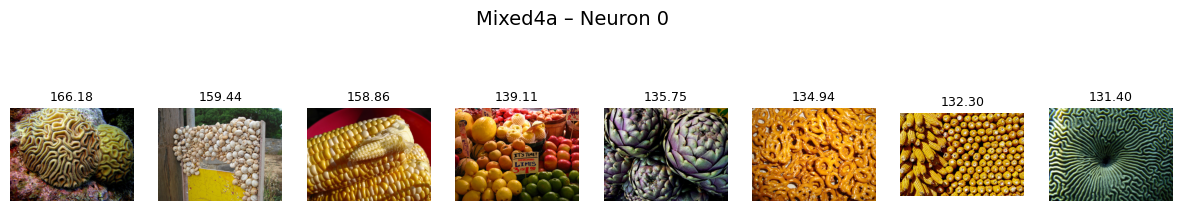

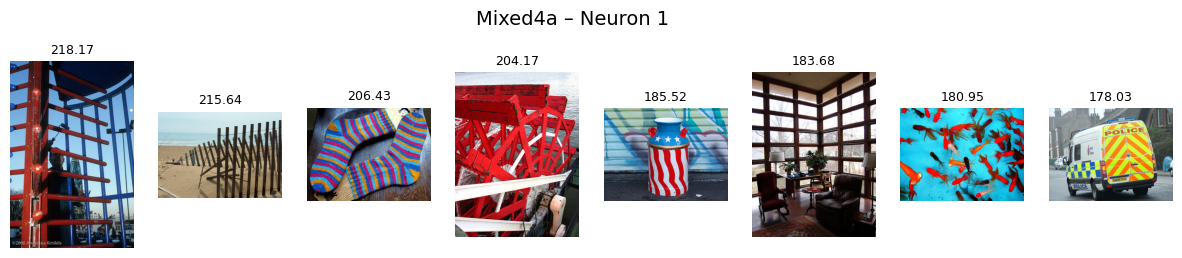

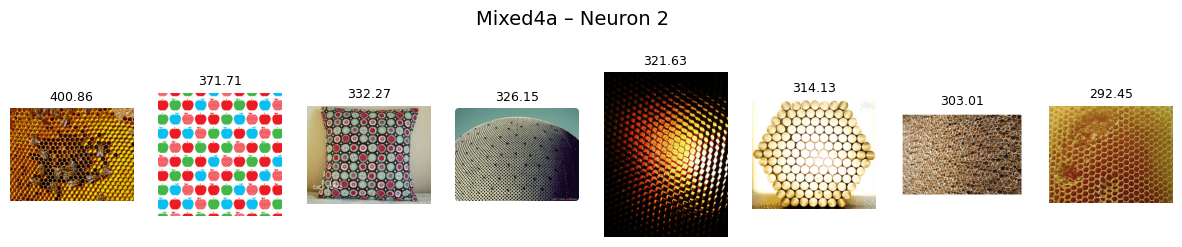

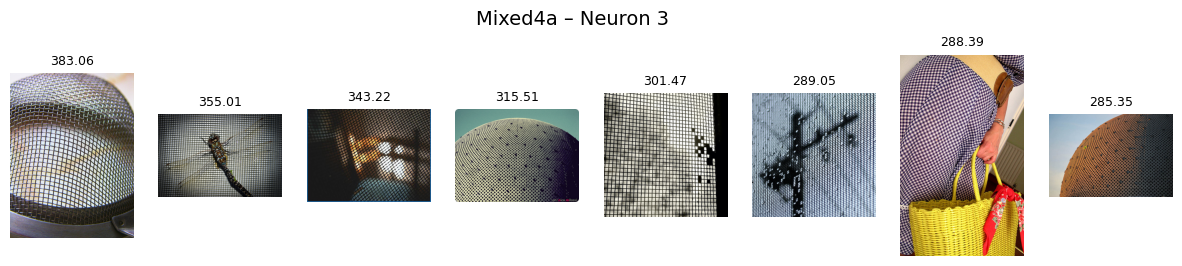

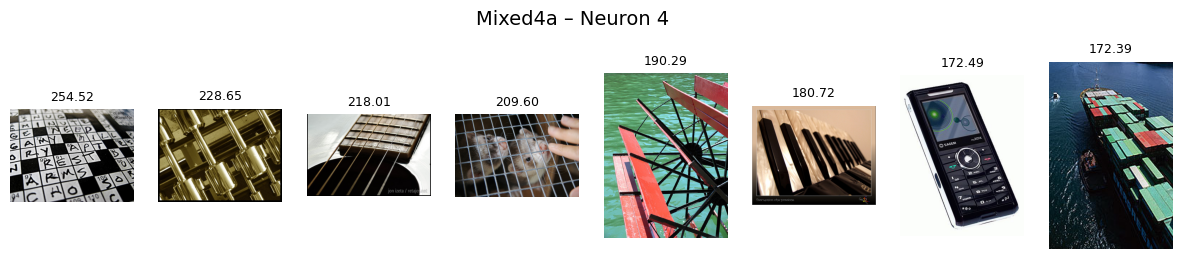

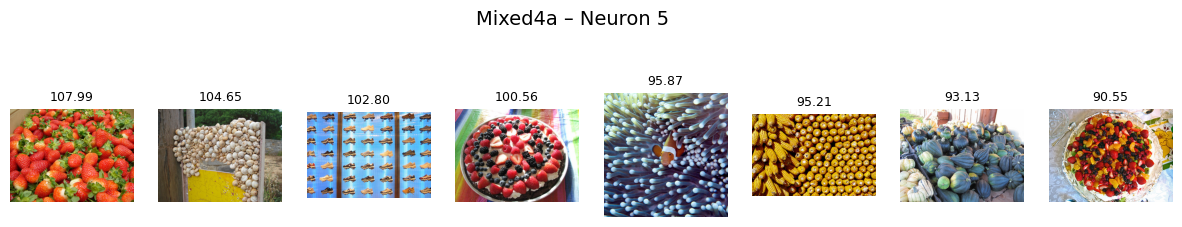

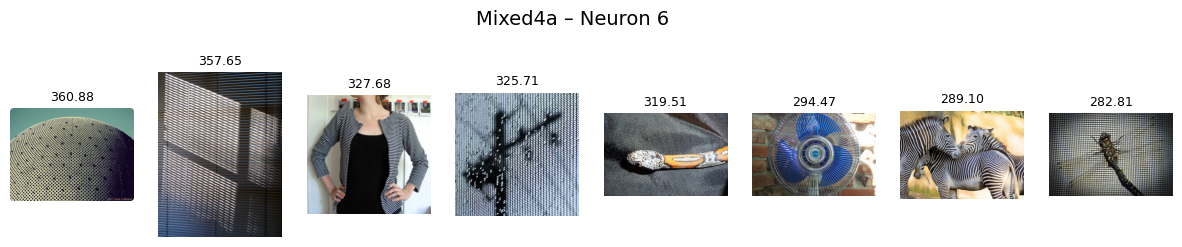

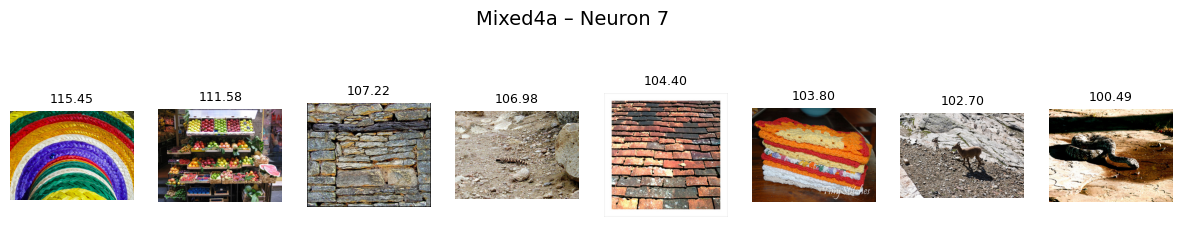

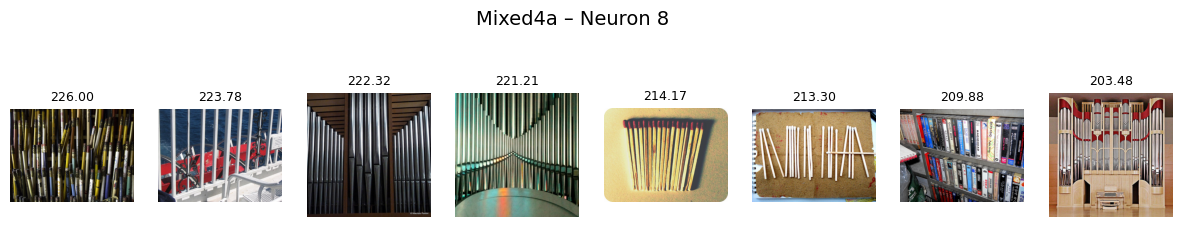

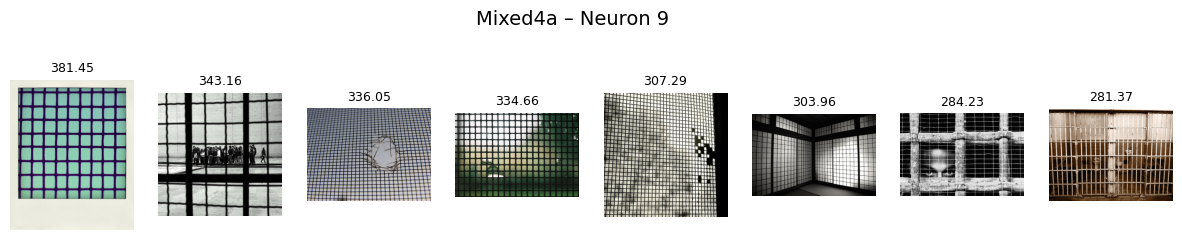

In [16]:
IMAGENET_VAL_DIR = "../data/ILSVRC2012_img_val"

for neuron_id in range(10):
    visualize_neuron(
        neuron_id,
        top_images_per_neuron,
        IMAGENET_VAL_DIR,
        K=8
    )

In [43]:
from collections import defaultdict
import torch

activation_db = defaultdict(list)

with torch.no_grad():
    for images, indices, names in val_loader:
        images = images.to(device)

        # Forward pass
        _ = model(images)

        # Extract mixed4a activations
        mixed4a_acts = activations["mixed4a"]  # (B, C, H, W)

        # Compute activation scores
        scores = compute_activation_scores(mixed4a_acts, num_neurons=10, metric="sum")
        # shape: (B, 10)

        for i in range(scores.size(0)):
            for neuron_idx in range(10):
                activation_db[neuron_idx].append({
                    "image_index": indices[i].item(),
                    "image_name": names[i],
                    "score": scores[i, neuron_idx].item()
                })

/home/musty/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [44]:
TOP_K = 20  # or 10, or 50 — your choice

top_images_per_neuron = {}

for neuron_id in range(10):
    # Sort by activation score (descending)
    sorted_acts = sorted(
        activation_db[neuron_id],
        key=lambda x: x['score'],
        reverse=True
    )

    top_images_per_neuron[neuron_id] = sorted_acts[:TOP_K]


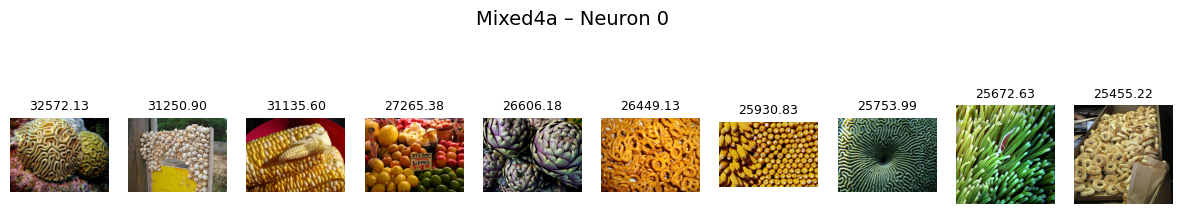

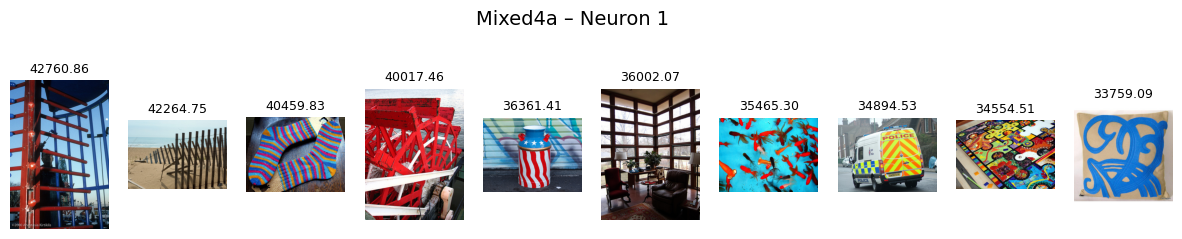

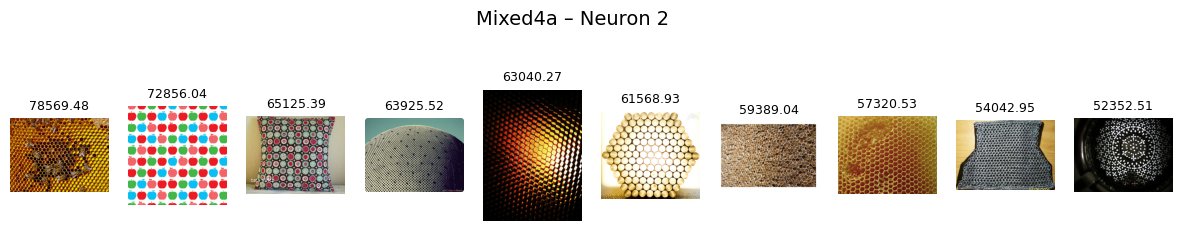

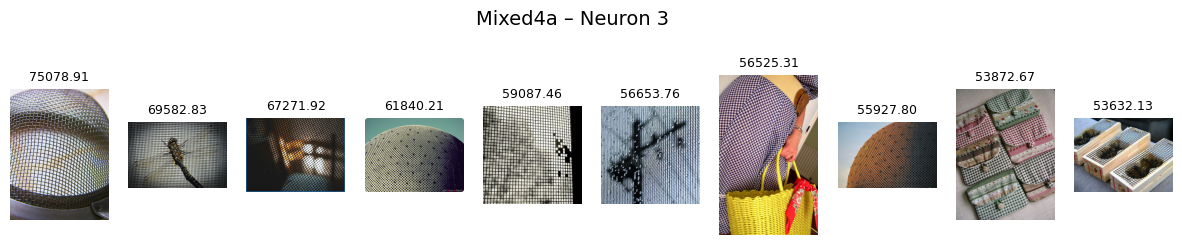

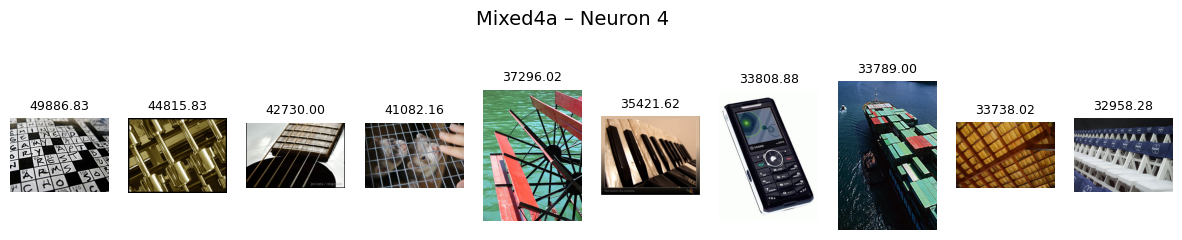

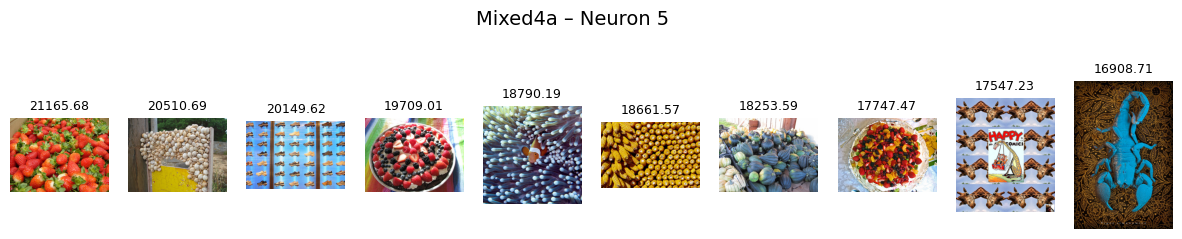

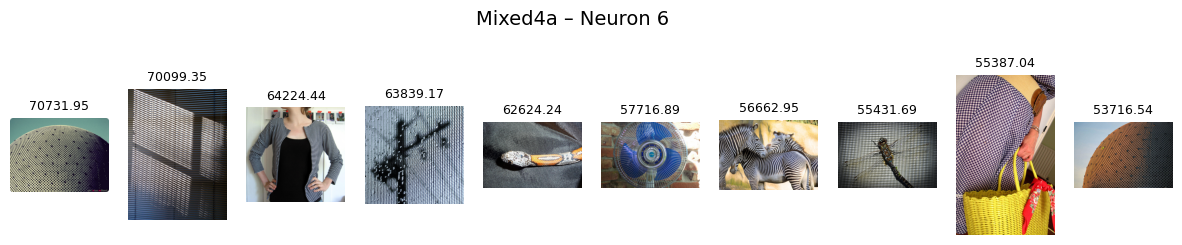

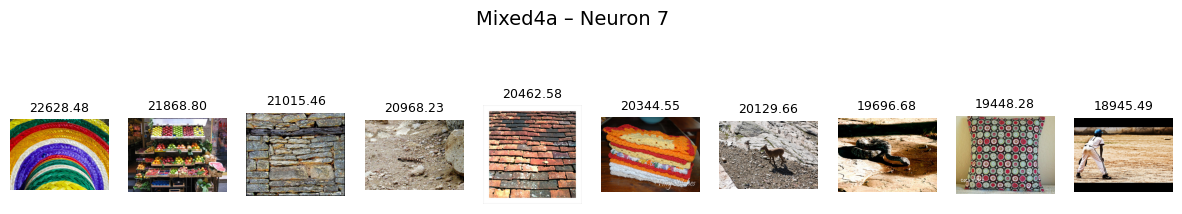

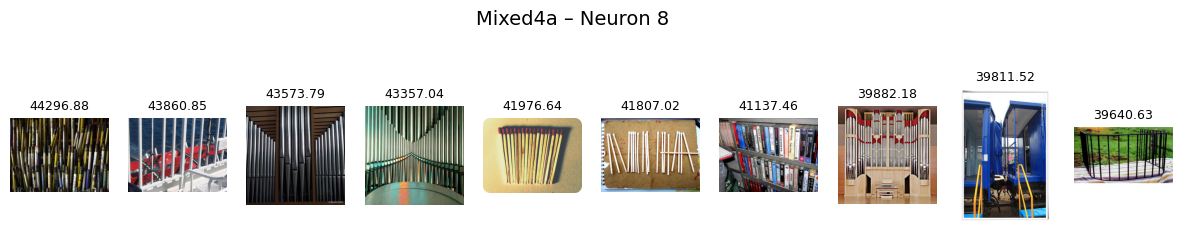

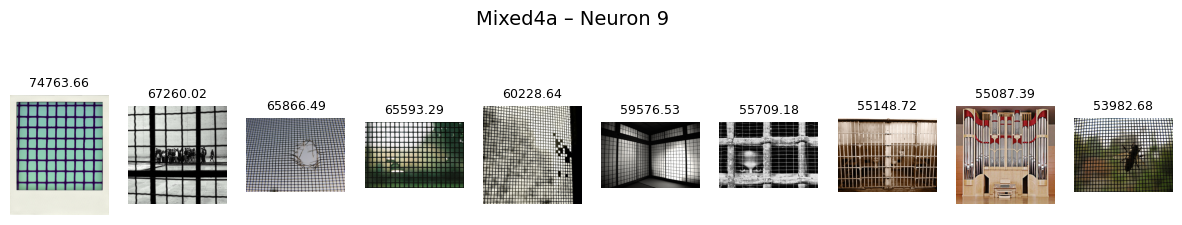

In [45]:
IMAGENET_VAL_DIR = "../data/ILSVRC2012_img_val"

for neuron_id in range(10):
    visualize_neuron(
        neuron_id,
        top_images_per_neuron,
        IMAGENET_VAL_DIR,
        K=10
    )

In [46]:
from collections import defaultdict
import torch

activation_db = defaultdict(list)

with torch.no_grad():
    for images, indices, names in val_loader:
        images = images.to(device)

        # Forward pass
        _ = model(images)

        # Extract mixed4a activations
        mixed4a_acts = activations["mixed4a"]  # (B, C, H, W)

        # Compute activation scores
        scores = compute_activation_scores(mixed4a_acts, num_neurons=10, metric="max")
        # shape: (B, 10)

        for i in range(scores.size(0)):
            for neuron_idx in range(10):
                activation_db[neuron_idx].append({
                    "image_index": indices[i].item(),
                    "image_name": names[i],
                    "score": scores[i, neuron_idx].item()
                })

In [47]:
TOP_K = 20  # or 10, or 50 — your choice

top_images_per_neuron = {}

for neuron_id in range(10):
    # Sort by activation score (descending)
    sorted_acts = sorted(
        activation_db[neuron_id],
        key=lambda x: x['score'],
        reverse=True
    )

    top_images_per_neuron[neuron_id] = sorted_acts[:TOP_K]


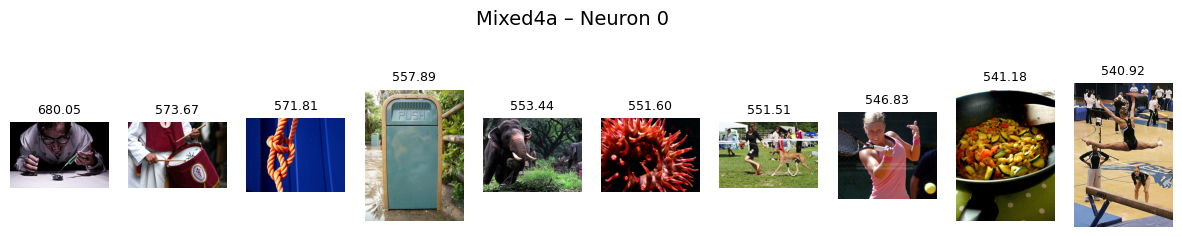

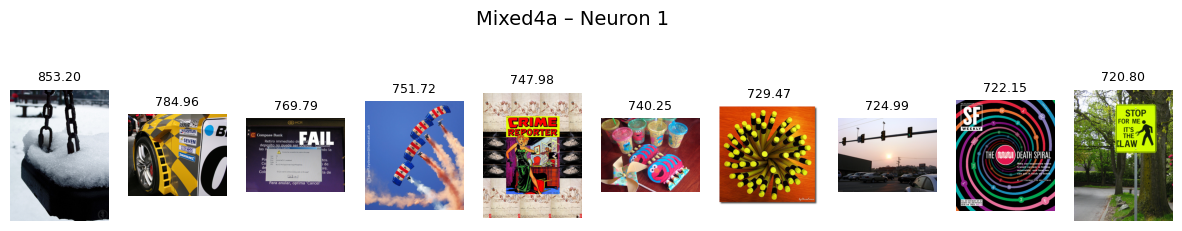

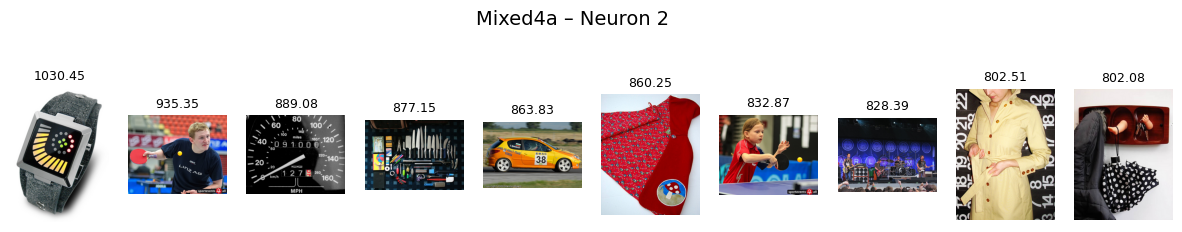

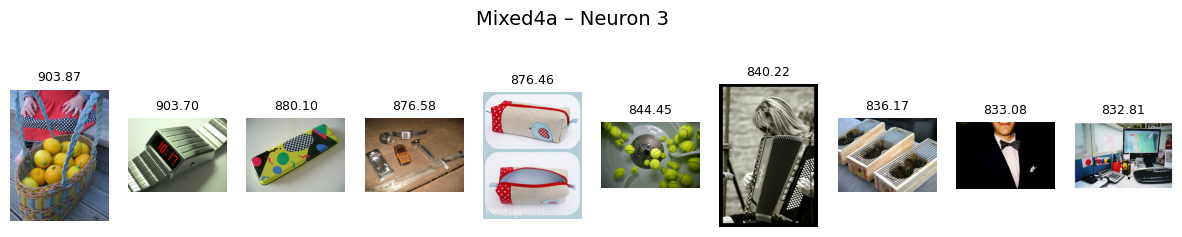

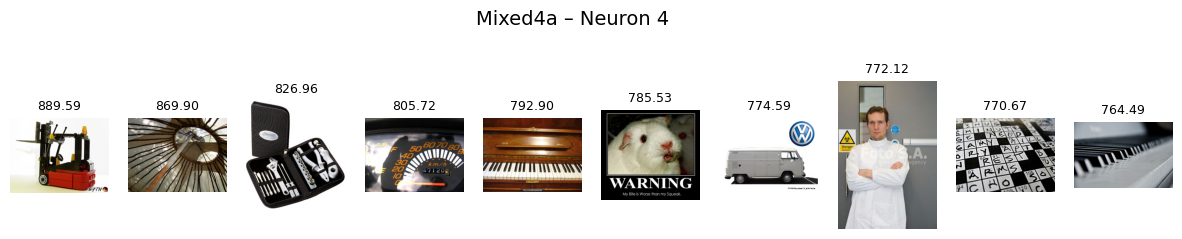

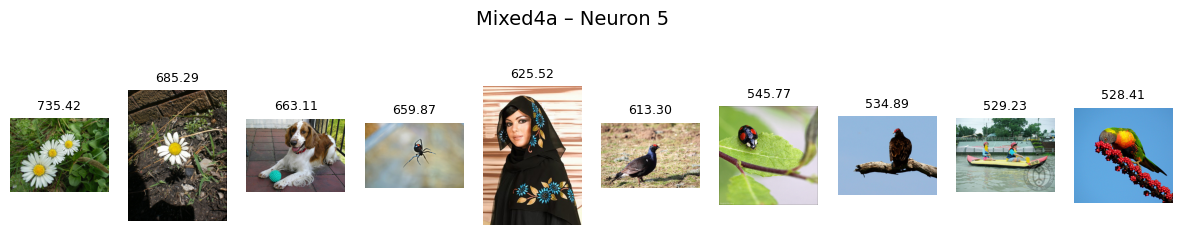

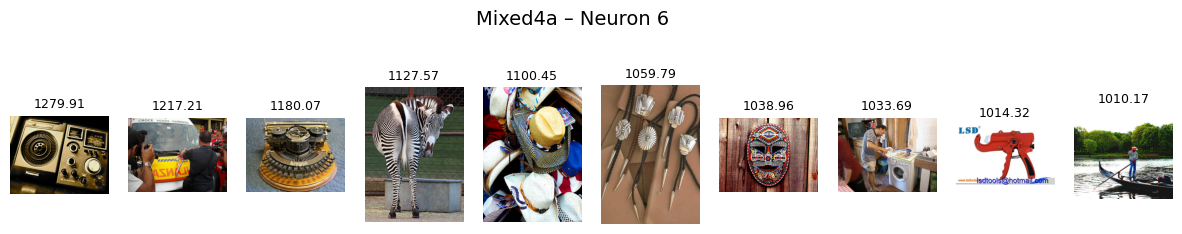

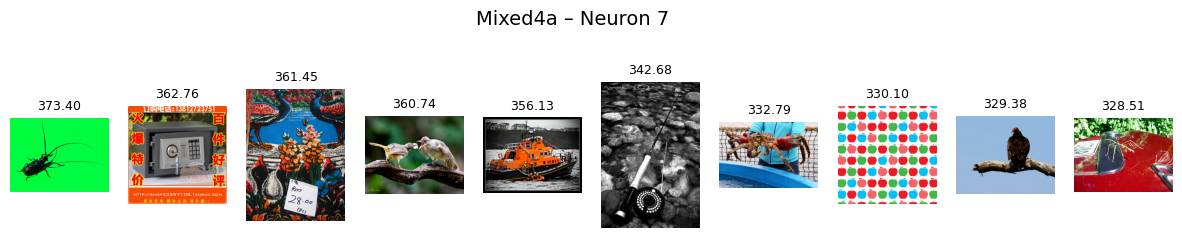

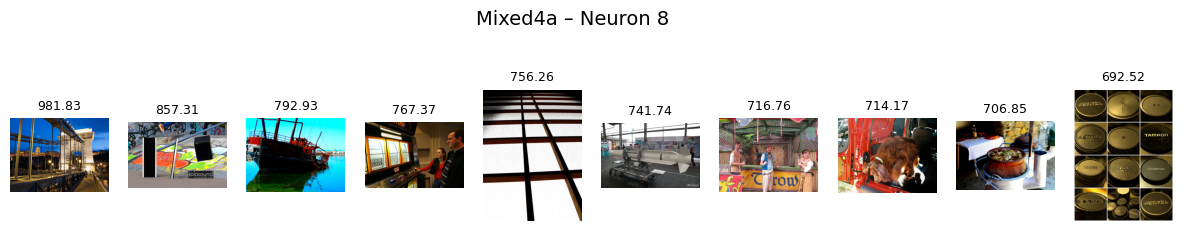

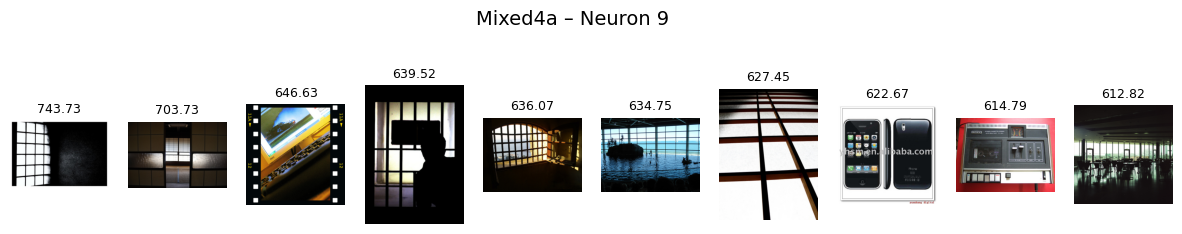

In [48]:
IMAGENET_VAL_DIR = "../data/ILSVRC2012_img_val"

for neuron_id in range(10):
    visualize_neuron(
        neuron_id,
        top_images_per_neuron,
        IMAGENET_VAL_DIR,
        K=10
    )